# Store Sales Forecasting, Day 1: Exploratory Data Analysis
**Competition:** [Kaggle, Store Sales: Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)

**Goal:** Forecast unit sales for Corporación Favorita grocery stores in Ecuador (54 stores, 33 product families, 2013–2017).

**Evaluation Metric:** RMSLE (Root Mean Squared Log Error), penalizes under-prediction and handles the heavy right-skew in sales distribution.

---
**What this notebook covers:**
- Data loading and shape validation
- Data audit (nulls, ranges, distributions)
- Time-series trend analysis
- External factor analysis (oil prices, holidays, earthquakes)
- Store & product family analysis
- Feature engineering insights for Day 2

In [2]:
%pip install pandas numpy matplotlib seaborn plotly statsmodels kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Data Loading
Load all 6 CSV files. Key observations:
- **Train:** 3,000,888 rows × 6 columns | Date range: Jan 2013 → Aug 15, 2017
- **Test:** 28,512 rows | Forecast horizon: Aug 16–31, 2017 (16 days)
- **54 stores**, **33 product families**
- Supporting files: `oil.csv`, `holidays_events.csv`, `transactions.csv`, `stores.csv`

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (14,5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Success: Libraries imported")

Success: Libraries imported


In [4]:
train = pd.read_csv('../data/train.csv', parse_dates = ['date'])
test = pd.read_csv('../data/test.csv', parse_dates = ['date'])
stores = pd.read_csv('../data/stores.csv')
oil = pd.read_csv('../data/oil.csv', parse_dates = ['date'])
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates = ['date'])
transactions = pd.read_csv('../data/transactions.csv', parse_dates = ['date'])
submission = pd.read_csv('../data/sample_submission.csv')

print(f"train shape : {train.shape}")
print(f"test shape : {test.shape}")
print(f"stores shape : {stores.shape}")
print(f"oil shape : {oil.shape}")
print(f"holidays shape : {holidays.shape}")
print(f"transactions shape : {transactions.shape}")

print(f"Train date range : {train['date'].min()} -> {train['date'].max()}")
print(f"Test date range : {test['date'].min()} -> {test['date'].max()}")
print(f"Unique stores : {train['store_nbr'].nunique()}")
print(f"Unique families : {train['family'].nunique()}")

print("Success: Data Loaded with basic info")

train shape : (3000888, 6)
test shape : (28512, 5)
stores shape : (54, 5)
oil shape : (1218, 2)
holidays shape : (350, 6)
transactions shape : (83488, 3)
Train date range : 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test date range : 2017-08-16 00:00:00 -> 2017-08-31 00:00:00
Unique stores : 54
Unique families : 33
Success: Data Loaded with basic info


## 3. Data Audit
Systematic check for nulls, data types, value ranges, and data quality issues across all files.

In [5]:
print("Data Audit")
print("Train Data")
display(train.head(10))
display(train.describe())
display(train.isnull().sum().to_frame("missing"))

print("Oil NULL Check")
display(oil.isnull().sum().to_frame("missing"))

print("Holidays unique types")
print(holidays['type'].value_counts())
print("Transferred holidays")
display(holidays[holidays['transferred'] == True].head(10))

print("Stores")
display(stores)

Data Audit
Train Data


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0
5,5,2013-01-01,1,BREAD/BAKERY,0.00,0
6,6,2013-01-01,1,CELEBRATION,0.00,0
7,7,2013-01-01,1,CLEANING,0.00,0
8,8,2013-01-01,1,DAIRY,0.00,0
9,9,2013-01-01,1,DELI,0.00,0


,id,date,store_nbr,sales,onpromotion
count,3000888.00,3000888,3000888.00,3000888.00,3000888.00
mean,1500443.50,2015-04-24 08:27:04.703088384,27.50,357.78,2.60
min,0.00,2013-01-01 00:00:00,1.00,0.00,0.00
25%,750221.75,2014-02-26 18:00:00,14.00,0.00,0.00
50%,1500443.50,2015-04-24 12:00:00,27.50,11.00,0.00
75%,2250665.25,2016-06-19 06:00:00,41.00,195.85,0.00
max,3000887.00,2017-08-15 00:00:00,54.00,124717.00,741.00
std,866281.89,NaN,15.59,1102.00,12.22


,missing
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


Oil NULL Check


,missing
date,0
dcoilwtico,43


Holidays unique types
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64
Transferred holidays


,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True


Stores


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


### 🔍 Data Audit Findings

**Train Data (3,000,888 rows, zero nulls)**
| Metric | Sales | OnPromotion |
|--------|-------|-------------|
| Mean | 357.78 | 2.60 |
| Median (50%) | **11.00** | 0.00 |
| 75th percentile | 195.85 | 0.00 |
| Max | 124,717 | 741 |

> **Critical Insight:** The mean (357) vs median (11) gap signals extreme right-skew.  
> 25th percentile sales = 0.00, bottom 25% of all rows are **structural zeros** (not missing data).  
> **Action:** Use `log1p(sales)` as model target. This directly justifies RMSLE as the evaluation metric.

---

**Oil Data, 43 Nulls**
> Missing values occur because oil markets are closed on weekends and public holidays, prices simply aren't published.  
> **Fix (Day 2):** Use `oil['dcoilwtico'].ffill()`, forward-fill, NOT interpolation (interpolation would introduce future data leakage).

---

**Holidays Data, 6 Types, 10 Transferred Holidays**
> `transferred=True` + `type=Holiday` means the holiday was **moved to another date**, that original date is a normal working day.  
> The actual observed holiday appears as `type=Transfer` on a different row.  
> **Action (Day 2):** When creating a `is_holiday` feature, filter with `(type == 'Holiday') & (transferred == False)` to avoid corrupting ~10 dates.

---

**Stores, 5 Types (A–E), 17 Clusters**
> Only **8 stores are Type A** (highest tier), all in major cities: Quito (6), Ambato (1), Guayaquil (1), Manta (1).  
> **Action:** Encode `type` and `cluster` as categorical features, `cluster` is more powerful than raw `store_nbr` as it groups stores by behavioral similarity.

## 4. Sales Trend Analysis
Analyze total daily sales over the full training period (2013–2017) to identify trend, seasonality, and anomalies.

Total Sales over Time


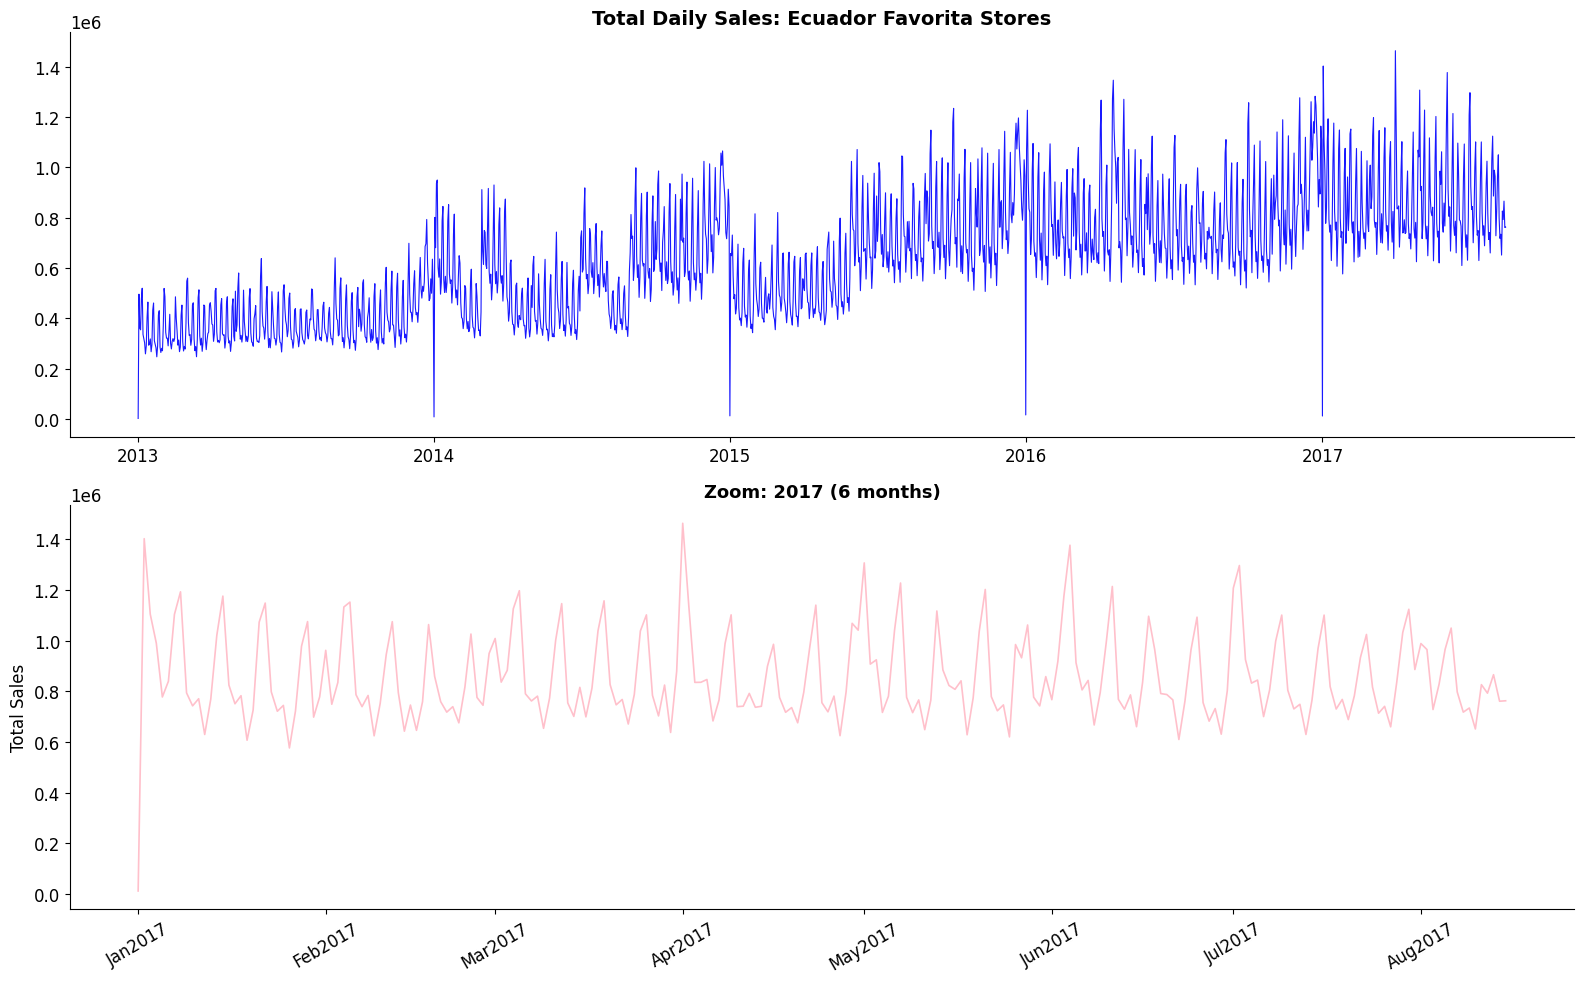

In [13]:
print("Total Sales over Time")
daily_sales = train.groupby('date')['sales'].sum().reset_index()
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full Trend
axes[0].plot(daily_sales['date'], daily_sales['sales'], color = 'blue', linewidth = 0.8, alpha = 0.9)
axes[0].set_title('Total Daily Sales: Ecuador Favorita Stores', fontsize = 14, fontweight = 'bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Last 6 months
recent = daily_sales[daily_sales['date'] >= '2017-01-01']
axes[1].plot(recent['date'], recent['sales'], color = 'pink', linewidth = 1.2)
axes[1].set_title("Zoom: 2017 (6 months)", fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Total Sales')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b%Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation = 30)
plt.tight_layout()
plt.savefig('../outputs/01_sales_trend.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### Sales Trend Findings
- **Clear upward trend:** Total daily sales grew from ~400K (2013) to ~800K–1.4M (2017), roughly 2.5× growth over 5 years.
- **Weekly seasonality:** The 2017 zoom view confirms a sharp recurring spike every ~7 days (weekends). Sunday is the peak sales day.
- **Spike near Jan 2013:** Near-zero sales on 2013-01-01 (New Year's Day), a complete store closure. This pattern repeats for other national holidays.
- **Feature to create (Day 2):** `day_of_week`, `is_weekend`, `week_of_year`, `month`, all confirmed useful by this chart.

## 5. Product Family Analysis
Identify which product families dominate revenue and how concentrated the distribution is.

Sales by Product Family


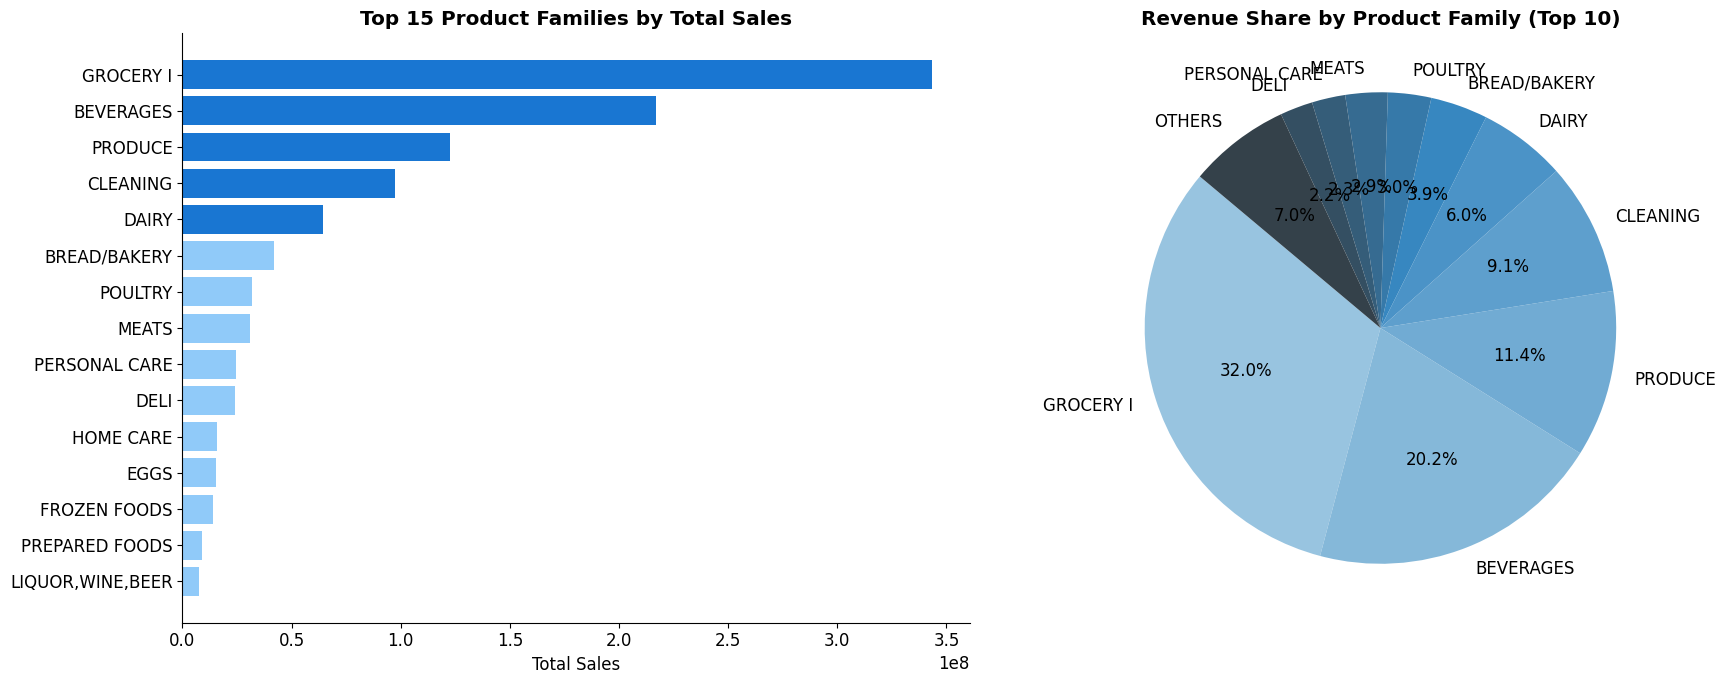

Top 5 Revenue Drivers
   family  sales_pct
GROCERY I      31.99
BEVERAGES      20.21
  PRODUCE      11.43
 CLEANING       9.08
    DAIRY       6.01


In [17]:
print("Sales by Product Family")
family_sales = (train.groupby('family')['sales'].sum().sort_values(ascending = False).reset_index())
family_sales['sales_pct'] = (family_sales['sales'] / family_sales['sales'].sum() * 100).round(2)

fig, axes = plt.subplots(1 ,2, figsize = (18, 7))

# Top 15 families (Bar chart)
top15 = family_sales.head(15)
colors = ['#1976D2' if i < 5 else '#90CAF9' for i in range(15)]
axes[0].barh(top15['family'][::-1], top15['sales'][::-1], color = colors[::-1])
axes[0].set_title("Top 15 Product Families by Total Sales", fontweight = 'bold')
axes[0].set_xlabel('Total Sales')

# Top 10 families (Pie Chart)
top10 = family_sales.head(10)
others_pct = family_sales.iloc[10:]['sales_pct'].sum()
top10_pie = pd.concat([top10, pd.DataFrame([{'family' : 'OTHERS', 'sales' : family_sales.iloc[10:]['sales'].sum(), 'sales_pct' : others_pct}])])
axes[1].pie(top10_pie['sales'], labels = top10_pie['family'], autopct = '%1.1f%%', startangle = 140, colors = sns.color_palette("Blues_d", len(top10_pie)))
axes[1].set_title("Revenue Share by Product Family (Top 10)", fontweight = 'bold')

plt.tight_layout()
plt.savefig('../outputs/02_family_sales.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print("Top 5 Revenue Drivers")
print(family_sales[['family', 'sales_pct']].head(5).to_string(index = False))

### Product Family Findings
- **Top 3 families dominate:** GROCERY I (32%), BEVERAGES (20.2%), PRODUCE (11.4%) together account for **63.6% of all revenue**.
- **Long tail exists:** The bottom 18 families collectively contribute less than BEVERAGES alone.
- **Implication for modeling:** Consider training separate models for the top 5 families vs the rest, error on GROCERY I impacts your RMSLE score far more than error on BOOKS or BABY CARE.
- The `family` column should be **one-hot encoded or target-encoded** as a feature (33 categories).

## 6. Store & Geographic Analysis
Understand revenue concentration by store, store type, and city.

Store Performance Analysis


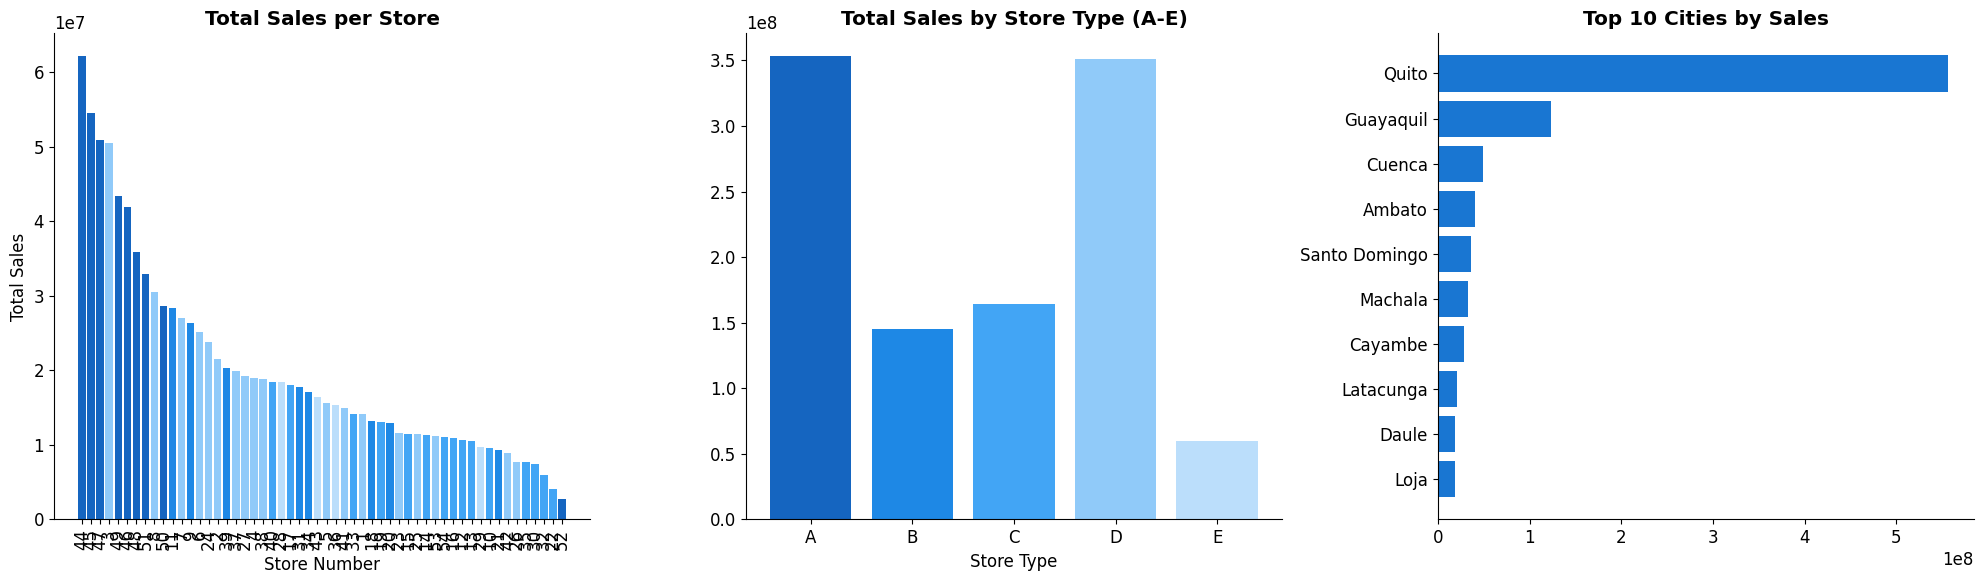

In [21]:
print("Store Performance Analysis")
store_sales = (train.groupby('store_nbr')['sales'].sum().reset_index().merge(stores, on = 'store_nbr'))
fig, axes = plt.subplots(1, 3, figsize = (20, 6))

# Store ranking
store_sorted = store_sales.sort_values('sales', ascending = False)
palette = {
    'A' : '#1565C0',
    'B' : '#1E88E5',
    'C' : '#42A5F5',
    'D' : '#90CAF9',
    'E' : '#BBDEFB'
}
colors_bar = [palette[t] for t in store_sorted['type']]

axes[0].bar(store_sorted['store_nbr'].astype(str), store_sorted['sales'], color = colors_bar)
axes[0].set_title("Total Sales per Store", fontweight = 'bold')
axes[0].set_xlabel("Store Number")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis = 'x', rotation = 90)

# By Store Type
type_sales = store_sales.groupby('type')['sales'].sum().reset_index()
axes[1].bar(type_sales['type'], type_sales['sales'], color = [palette[t] for t in type_sales['type']])
axes[1].set_title("Total Sales by Store Type (A-E)", fontweight = 'bold')
axes[1].set_xlabel('Store Type')


# By City
city_sales = (store_sales.groupby('city')['sales'].sum().sort_values(ascending = False).head(10))

axes[2].barh(city_sales.index[::-1], city_sales.values[::-1], color='#1976D2')
axes[2].set_title("Top 10 Cities by Sales", fontweight = 'bold')

plt.tight_layout()
plt.savefig('../outputs/03_store_analysis.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### Store Analysis Findings
- **Extreme store-level revenue concentration:** The top 5 stores (all Type A, all Quito) generate disproportionately more than the bottom 30 stores.
- **Type A vs Type E gap:** Type A stores (~3.5×10⁸ total) vs Type E stores (~0.65×10⁸), Type A stores generate ~5× more revenue.
- **Geographic dominance of Quito:** Quito generates ~5.5×10⁸ total sales, roughly 4.5× more than Guayaquil (2nd place at ~1.2×10⁸).
- **Modeling implication:** Train separate models per store cluster, or add `store_type` and `cluster` as strong categorical features in a single model.

## 7. External Factor Analysis
### 7a. Oil Price Correlation
Ecuador is a petroleum-dependent economy. Oil revenues directly affect consumer purchasing power and retail sales.

Oil Price vs Sales Correlation (Ecuador's Key Feature)


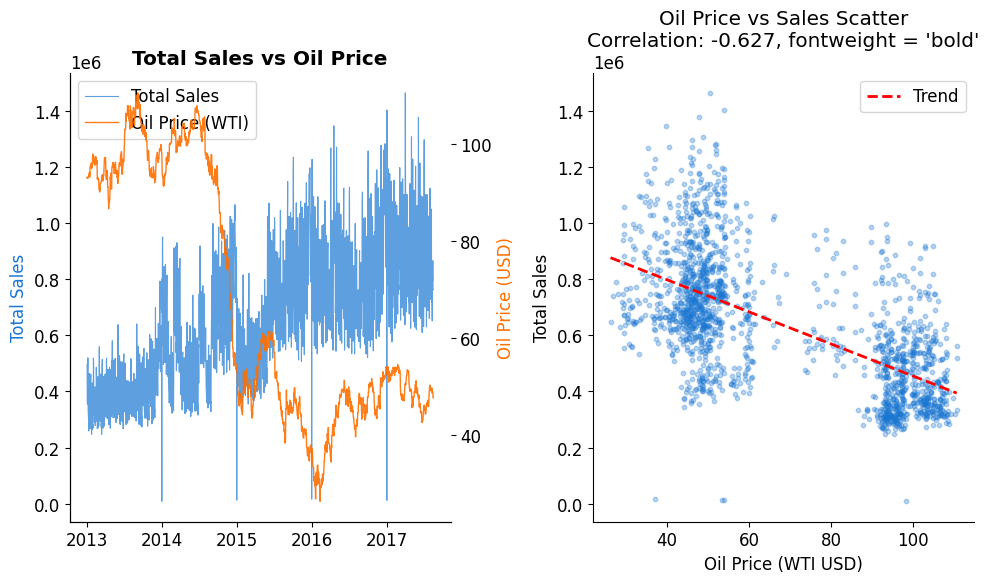

In [32]:
print("Oil Price vs Sales Correlation (Ecuador's Key Feature)")

# Merge oil with daily sales
oil_clean = oil.copy()
daily_with_oil = daily_sales.merge(oil_clean, on = 'date', how = 'left')
daily_with_oil['dcoilwtico'] = daily_with_oil['dcoilwtico'].ffill()
daily_with_oil = daily_with_oil.dropna(subset = ['dcoilwtico'])

fig, axes = plt.subplots(1, 2, figsize = (10, 6))

# Oil Price vs Sales over time
ax1 = axes[0]
ax2 = ax1.twinx()
line1 = ax1.plot(daily_with_oil['date'], daily_with_oil['sales'], color = "#1976D2", label = 'Total Sales', linewidth = 0.8, alpha = 0.7)
line2 = ax2.plot(daily_with_oil['date'], daily_with_oil['dcoilwtico'], color = '#FF6F00', label = 'Oil Price (WTI)', linewidth = 1.0, alpha = 0.9)
ax1.set_ylabel('Total Sales', color = "#1976D2")
ax2.set_ylabel("Oil Price (USD)", color = '#FF6F00')
ax1.set_title("Total Sales vs Oil Price", fontweight = 'bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc = 'upper left')

# Scatter: Correlation between Oil Price and Sales
axes[1].scatter(daily_with_oil['dcoilwtico'], daily_with_oil['sales'], alpha = 0.3, color = '#1976D2', s = 10)
corr = daily_with_oil[['sales', 'dcoilwtico']].corr().iloc[0,1]
axes[1].set_title(f"Oil Price vs Sales Scatter\nCorrelation: {corr:.3f}, fontweight = 'bold'")
axes[1].set_xlabel("Oil Price (WTI USD)")
axes[1].set_ylabel("Total Sales")

# Trend Line
z = np.polyfit(daily_with_oil['dcoilwtico'], daily_with_oil['sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_with_oil['dcoilwtico'].min(), daily_with_oil['dcoilwtico'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth = 2, label = 'Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/04_oil_correlation.png", dpi = 150, bbox_inches = 'tight')
plt.show()


### Oil Price Findings
- **Correlation = -0.627** (moderate-strong negative relationship): as oil prices fell from ~$100 (2013–2014) to ~$30 (2015–2016), total sales actually **increased**.
- This is counter-intuitive at first, but logical: when the government's oil revenues fell, they introduced austerity measures and import tariffs → consumers shifted toward **local supermarket purchases** over imported goods.
- The relationship is **not linear**, the scatter plot shows high variance, especially at lower oil prices. Don't model this as a simple linear feature.
- **Feature to create (Day 2):** Rolling 7-day and 30-day average oil price, oil price lag features.

## 7b. Holiday & Day-of-Week Effect

Holiday Effect on Sales


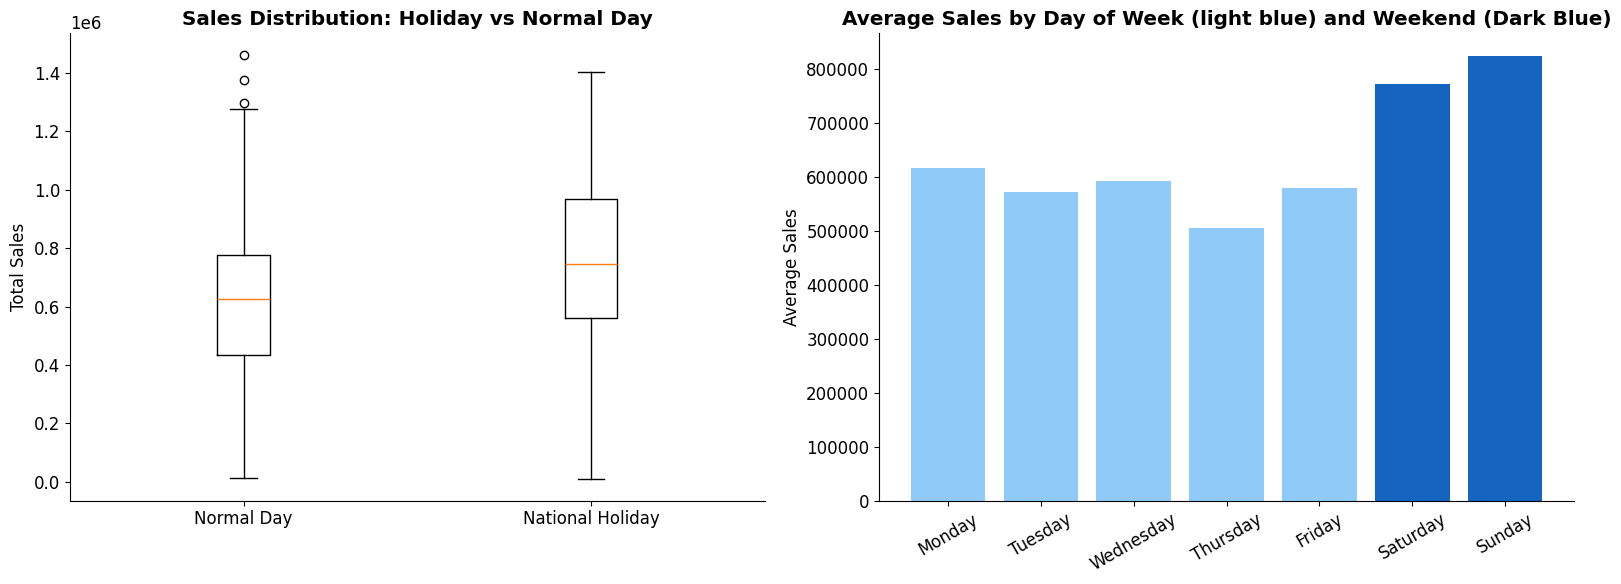

Avg sales on holidays : 756,225
Avg sales on normal days: 628,032
Holiday uplift        : 20.4%


In [33]:
print("Holiday Effect on Sales")

# Merge holidays (national only, not transferred)
national_holidays = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False) &
    (holidays['type'] != "Work Day")
]['date'].unique()

daily_with_oil['is_holiday'] = daily_with_oil['date'].isin(national_holidays)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Holiday vs Non-Holiday (boxplot)
holiday_group = daily_with_oil.groupby('is_holiday')['sales'].apply(list)
axes[0].boxplot([holiday_group[False], holiday_group[True]], labels = ['Normal Day', 'National Holiday'])
axes[0].set_title("Sales Distribution: Holiday vs Normal Day", fontweight = 'bold')
axes[0].set_ylabel("Total Sales")

# Average sales by day of week
daily_with_oil['dayofweek'] = daily_with_oil['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = (daily_with_oil.groupby('dayofweek')['sales'].mean().reindex(dow_order))
colors_dow = ['#90CAF9'] * 5 + ['#1565C0'] * 2
axes[1].bar(dow_sales.index, dow_sales.values, color = colors_dow)
axes[1].set_title("Average Sales by Day of Week (light blue) and Weekend (Dark Blue)", fontweight = "bold")
axes[1].set_ylabel("Average Sales")
axes[1].tick_params(axis = 'x', rotation = 30)

plt.tight_layout()
plt.savefig('../outputs/05_holiday_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

avg_holiday = daily_with_oil[daily_with_oil['is_holiday']]['sales'].mean()
avg_normal  = daily_with_oil[~daily_with_oil['is_holiday']]['sales'].mean()
print(f"Avg sales on holidays : {avg_holiday:,.0f}")
print(f"Avg sales on normal days: {avg_normal:,.0f}")
print(f"Holiday uplift        : {((avg_holiday/avg_normal)-1)*100:.1f}%")

### Holiday & Day-of-Week Findings
- **National Holidays drive higher sales:** The holiday box plot shows a higher median (~750K) vs normal days (~620K). Holidays bring shopping sprees, not closures, typical for grocery retail.
- **Weekend effect is very strong:** Saturday and Sunday average 770K and 825K respectively, vs 500K–620K on weekdays. Thursday is the weakest day.
- **Feature to create (Day 2):** `is_holiday` (national only), `day_of_week` (0–6 integer), `is_weekend` (binary).

## 8. Promotion Effect Analysis
Analyze how `onpromotion` (number of items on promotion per day per store-family) affects sales across product families.

Promotion Effect Analysis


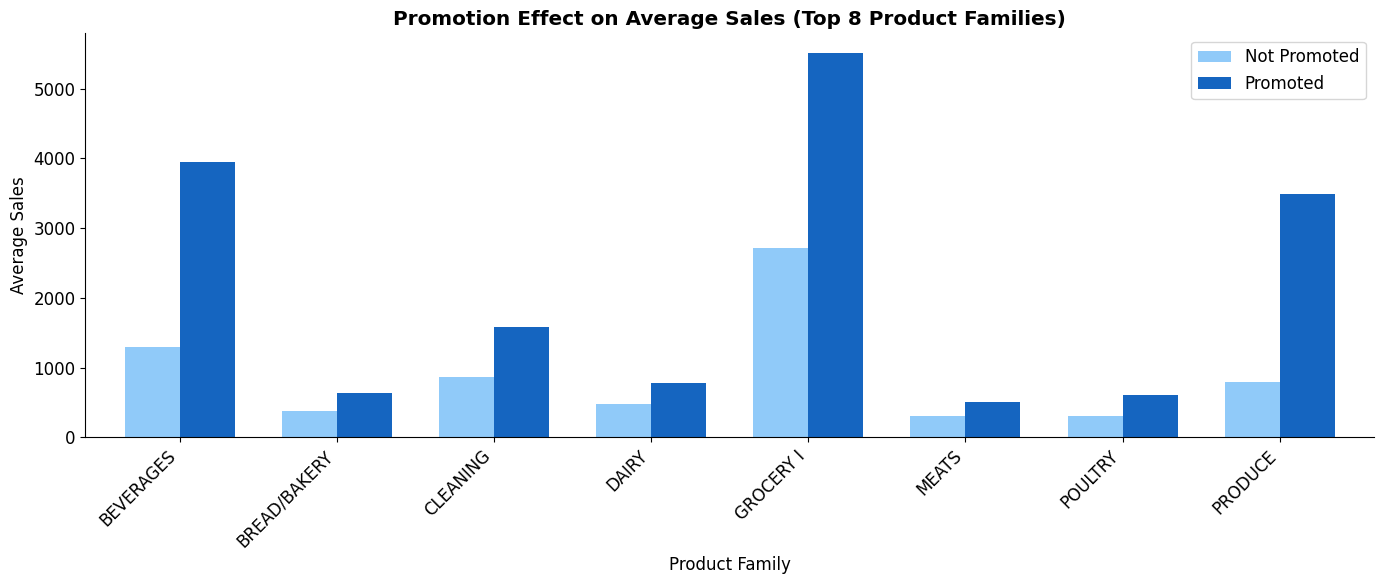

In [38]:
print("Promotion Effect Analysis")

# Promoted vs not by family
promo_effect = (train.groupby(['family', 'onpromotion']).agg(avg_sales = ('sales', 'mean')).reset_index())
promo_effect['onpromotion'] = promo_effect['onpromotion'].apply(lambda x : 'Promoted' if x > 0 else "Not Promoted")

top8_families = family_sales.head(8)['family'].tolist()
promo_top8 = promo_effect[promo_effect['family'].isin(top8_families)]

fig, ax = plt.subplots(figsize = (14, 6))
promo_pivot = promo_top8.pivot_table(index='family', columns='onpromotion', values='avg_sales', aggfunc='mean')
promo_pivot.plot(
    kind = 'bar',
    ax = ax,
    color = ['#90CAF9', '#1565C0'],
    width = 0.7
)
ax.set_title("Promotion Effect on Average Sales (Top 8 Product Families)", fontweight = 'bold')
ax.set_xlabel("Product Family")
ax.set_ylabel("Average Sales")
ax.legend(["Not Promoted", 'Promoted'])

plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig("../outputs/06_promotion_effect.png", dpi = 150, bbox_inches = 'tight')
plt.show()

### Promotion Findings
- **Promotions consistently increase sales across all 8 families shown.** The lift is not uniform:
  - **BEVERAGES:** ~3× lift (1,300 → 4,000), highest absolute promotion gain
  - **GROCERY I:** Highest base sales (~2,700) but moderate lift to ~5,500
  - **PRODUCE:** ~4× lift from a relatively low base (~800 → 3,500)
  - **BREAD/BAKERY, DAIRY, MEATS, POULTRY:** Smaller absolute lifts but consistent positive effect
- `onpromotion` is one of the **strongest predictors in this competition**, do not drop it.
- **Feature to create (Day 2):** `onpromotion` as-is, plus `promo_lag_1`, `promo_lag_7` to capture delayed promotion effects.

## 9. Earthquake Impact Analysis
A magnitude 7.8 earthquake struck Ecuador on **April 16, 2016**, causing a significant disruption to normal sales patterns.

Earthquake Impact Analysis (April 16, 2016)


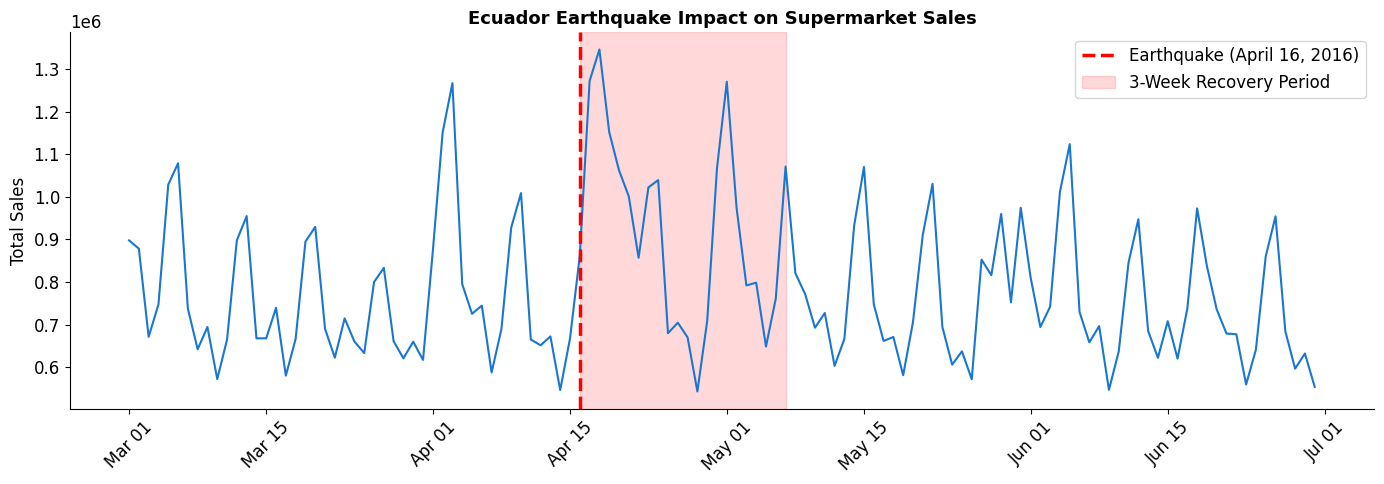

In [41]:
print("Earthquake Impact Analysis (April 16, 2016)")
earthquake_date = pd.Timestamp('2016-04-16')
window = daily_sales[(daily_sales['date'] >= '2016-03-01') & (daily_sales['date'] <= '2016-06-30')].copy()

fig, ax = plt.subplots(figsize = (14, 5))
ax.plot(window['date'], window['sales'], color = '#1976D2', linewidth = 1.5)
ax.axvline(x = earthquake_date, color = 'red', linestyle = '--', linewidth = 2.5, label = "Earthquake (April 16, 2016)")
ax.axvspan(earthquake_date, earthquake_date + pd.Timedelta(weeks = 3), alpha = 0.15, color = 'red', label = '3-Week Recovery Period')
ax.set_title("Ecuador Earthquake Impact on Supermarket Sales", fontsize = 13, fontweight = 'bold')
ax.set_ylabel('Total Sales')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("../outputs/07_earthquake_impact.png", dpi = 150, bbox_inches = 'tight')
plt.show()


### Earthquake Findings
- **Immediate demand spike (Apr 16–18):** Sales surged to ~1.35M on the day of the earthquake, panic buying of essentials (water, food, batteries).
- **Post-earthquake dip (Apr 20–28):** Sales crashed below 600K as stores were damaged or inaccessible and supply chains disrupted.
- **Secondary recovery spike (Apr 29–May 1):** Relief purchases and restocking drove another spike to ~1.27M.
- **Return to baseline:** By May 8 (3 weeks later), sales had normalized to pre-earthquake ranges.
- **Feature to create (Day 2):** `is_earthquake_period` binary flag covering Apr 16 – May 8, 2016. This prevents the model from learning the wrong pattern from this anomalous 3-week window.

## 10. EDA Summary & Day 2 Action Plan

### Key Findings
| Finding | Impact on Model |
|---------|----------------|
| Sales are heavily right-skewed (median=11, mean=358) | Use `log1p(sales)` as target |
| 25% of rows have zero sales | These are structural zeros, keep them |
| Oil price has -0.627 correlation with sales | Add rolling oil price features |
| Weekends sell 25–30% more than weekdays | Add `day_of_week`, `is_weekend` |
| National holidays → higher sales | Add `is_holiday` (with transferred fix) |
| Promotions → consistent sales lift | Keep `onpromotion`, add lag features |
| Earthquake April 16, 2016 | Add `is_earthquake_period` flag |
| Type A stores = 5× revenue of Type E | Encode `store_type` + `cluster` |
| GROCERY I + BEVERAGES = 52% of revenue | Consider family-specific models |